## Урок 8. Домашнее задание
### 8.1 Задание высокого уровня

Давайте проверим, как t-sne может улучшить Ваши модели. Для начала загрузим данные и построим Baseline модель без преобразования входных данных

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

def eval_model(input_x, input_y):
    """Обучаем и валидируем модель"""
    X_train, X_test, y_train, y_test = train_test_split(
        input_x, input_y, test_size=.3, stratify=y, random_state=42
    )
    # Для примера возьмём неглубокое дерево решений
    clf = DecisionTreeClassifier(max_depth=2, random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict_proba(X_test)
    acc_score = accuracy_score(y_test, preds.argmax(axis=1))
    print('Accuracy: %.5f' % acc_score)
file_path = 'C:/Users/user0907/client_segmentation_nsNGnC5.csv'
df_source = pd.read_csv(file_path)
X = df_source[['call_diff','sms_diff','traffic_diff']].values
y = df_source.customes_class.values

Вычисляем скор baseline модели (по тестовым данным)

In [3]:
eval_model(X, y)

Accuracy: 0.80000


In [4]:
from sklearn.decomposition import PCA

#понижаем размерность и обучаем модель преобразовать данные
pca = PCA(n_components=2).fit(X)
#применяем РСА
X_pca = pca.transform(X)
X_pca[:10]


array([[-0.75744517,  0.16623077],
       [-2.61154618,  0.5951692 ],
       [ 0.13301346, -0.37383597],
       [ 1.74983161,  0.27582433],
       [-2.69734129, -0.31624463],
       [ 0.70860533, -0.51547171],
       [ 1.27113452,  0.04822069],
       [-2.16755366,  0.04137214],
       [-2.58986361,  0.08695463],
       [ 1.6981062 , -1.16822327]])

In [5]:
eval_model(X_pca, y)

Accuracy: 0.83333


In [6]:
from sklearn.manifold import TSNE

tsne_transformer = TSNE(n_components=2)

x_tsne = tsne_transformer.fit_transform(X)
x_tsne[:10]

array([[ 0.91465205,  1.1550682 ],
       [ 0.91622806,  6.2676787 ],
       [ 1.3020008 , -0.8065208 ],
       [-3.736286  , -3.924875  ],
       [-0.68269235,  6.5850058 ],
       [-0.22883642, -1.6252626 ],
       [-3.9949694 , -2.9730282 ],
       [-0.07288285,  5.549155  ],
       [ 0.02010684,  6.512966  ],
       [ 2.2534032 , -3.4766247 ]], dtype=float32)

In [7]:
eval_model(x_tsne, y)
#вывод: на небольшой выборке данных Accuracy модель понижения размерности  TSNE показывает лучшие результаты

Accuracy: 0.90000


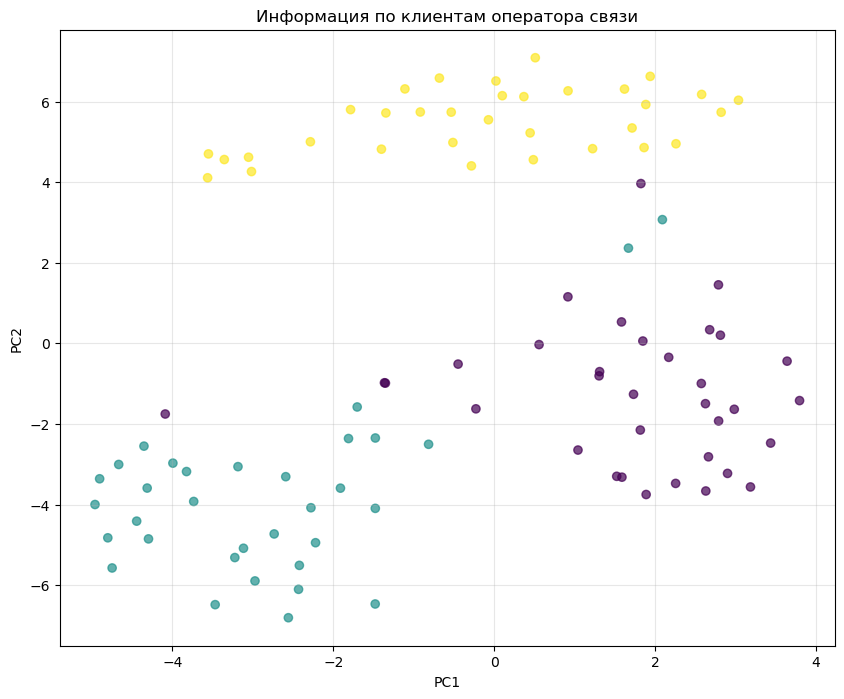

In [10]:
# И нарисуем получившиеся точки в нашем новом пространстве
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

#рисуем все точки
plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=y, cmap='viridis', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Информация по клиентам оператора связи')

plt.grid(True, alpha=0.3)
plt.show()

Алгоритм выполнения домашней работы:

* выполните PCA преобразование матрицы $X$, передайте новую матрицу в `eval_model`. Какое значение Accuracy получили?
* выполните t-sne преобразование матрицы $X$, передайте новую матрицу в `eval_model`. Какое значение Accuracy получили?

Какие выводы можно сделать?

В этом уроке мы познакомились с новым алгоритмом t-SNE. Какие у него есть недостатки?

* требует бережной настройки параметров на валидационной выборке (см. документацию - там очень много параметров)
* плохо работает, когда данных очень много.

На больших объёмах данных (более 10к элементов) следует применять более простые алгоритмы - PCA или SVD.